In [2]:
from Configurations.imports import *

In [3]:
x = 6 * np.random.rand(100, 1) - 3
x.shape

(100, 1)

In [4]:
y = 0.5 * x ** 2 + 1.5 * x + 2 + np.random.rand(100,1)
y.shape

(100, 1)

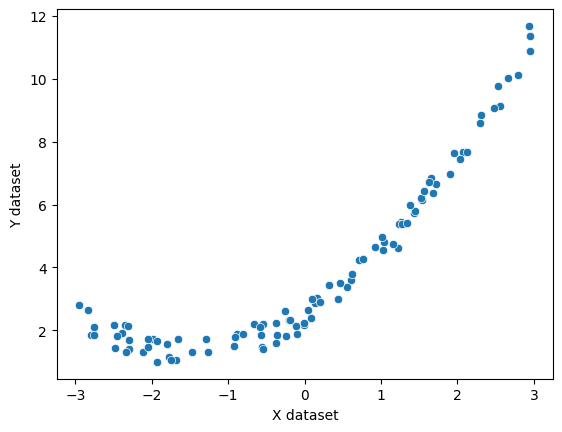

In [5]:
# lets visualize the data
sns.scatterplot(x=x.flatten(), y=y.flatten())
plt.xlabel("X dataset")
plt.ylabel("Y dataset")
plt.show()

In [6]:
# Data set split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [7]:
#first we are trying to implement linear regression here
from sklearn.linear_model import LinearRegression
regressor1 = LinearRegression(n_jobs=-1)

regressor1.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


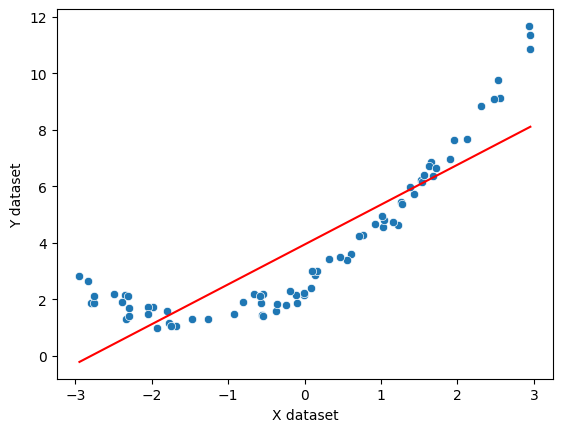

In [8]:
#visualize the model
sns.scatterplot(x=x_train.flatten(), y=y_train.flatten())
sns.lineplot(x=x_train.flatten(), y=regressor1.predict(x_train).flatten(), color="r")
plt.xlabel("X dataset")
plt.ylabel("Y dataset")
plt.show()

In [15]:
# lets see the performance 
from sklearn.metrics import r2_score
score = r2_score(y_train, regressor1.predict(x_train))
score

0.7496753568953136

In [16]:
# adjusted r2_score

adjusted_score = 1 - ((1 - score) * (len(y_test) - 1)) / (len(y_test) - x_test.shape[1] - 1)
adjusted_score

0.7387916767603273

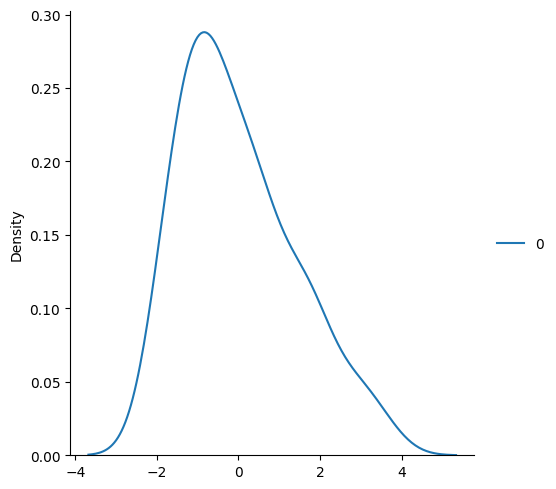

In [ ]:
residuals = y_train - regressor1.predict(x_train)
sns.displot(residuals, kind="kde")

# this shows right skewed distribution so there is something wrong 
"""
seaborn.displot is a Seaborn figure-level function designed to visualize the univariate or bivariate distribution of data. It acts as a wrapper for histplot(), kdeplot(), and ecdfplot(), offering a unified interface for histograms, kernel density estimates, and empirical cumulative distribution functions, typically in a stacked or faceted grid 
"""

In [ ]:
# polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=True)

####  `PolynomialFeatures(degree=2, include_bias=True)`

* **Purpose:**
  Generates polynomial features up to degree 2 from input data.

---

#### `degree = 2`

* Expands features to include:

  * Linear terms → `x`
  * Squared terms → `x²`
  * Interaction terms → `x1 * x2`

👉 Example:

```text
[x] → [1, x, x²]
[x1, x2] → [1, x1, x2, x1², x1*x2, x2²]
```

---

#### `include_bias = True`

* Adds a column of **1s** to the dataset
* Represents the **intercept (b₀)** in the model

---

#### Summary

* Adds polynomial + interaction features
* Helps capture **non-linear relationships**
* Still uses **linear regression underneath**

---


In [23]:
x_ploy_train = poly.fit_transform(x_train)
x_ploy_test = poly.transform(x_test)

In [24]:
regressor2 = LinearRegression(n_jobs=-1)
regressor2.fit(x_ploy_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [25]:
y_pred = regressor2.predict(x_ploy_test)

<Axes: >

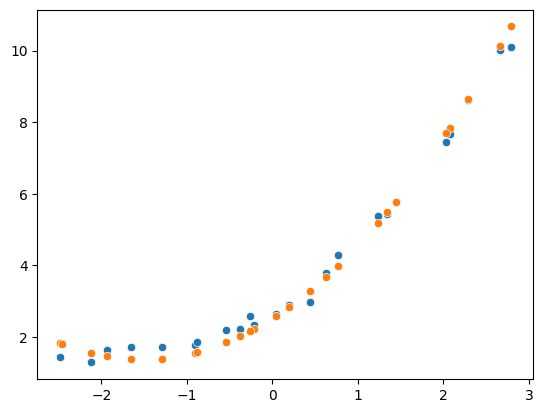

In [ ]:
sns.scatterplot(x=x_test.flatten(), y=y_test.flatten())
sns.scatterplot(x=x_test.flatten(), y=y_pred.flatten())
# now you can see the how our prediction is distributed


In [29]:
score = r2_score(y_test, y_pred)
score * 100

99.12393300615243